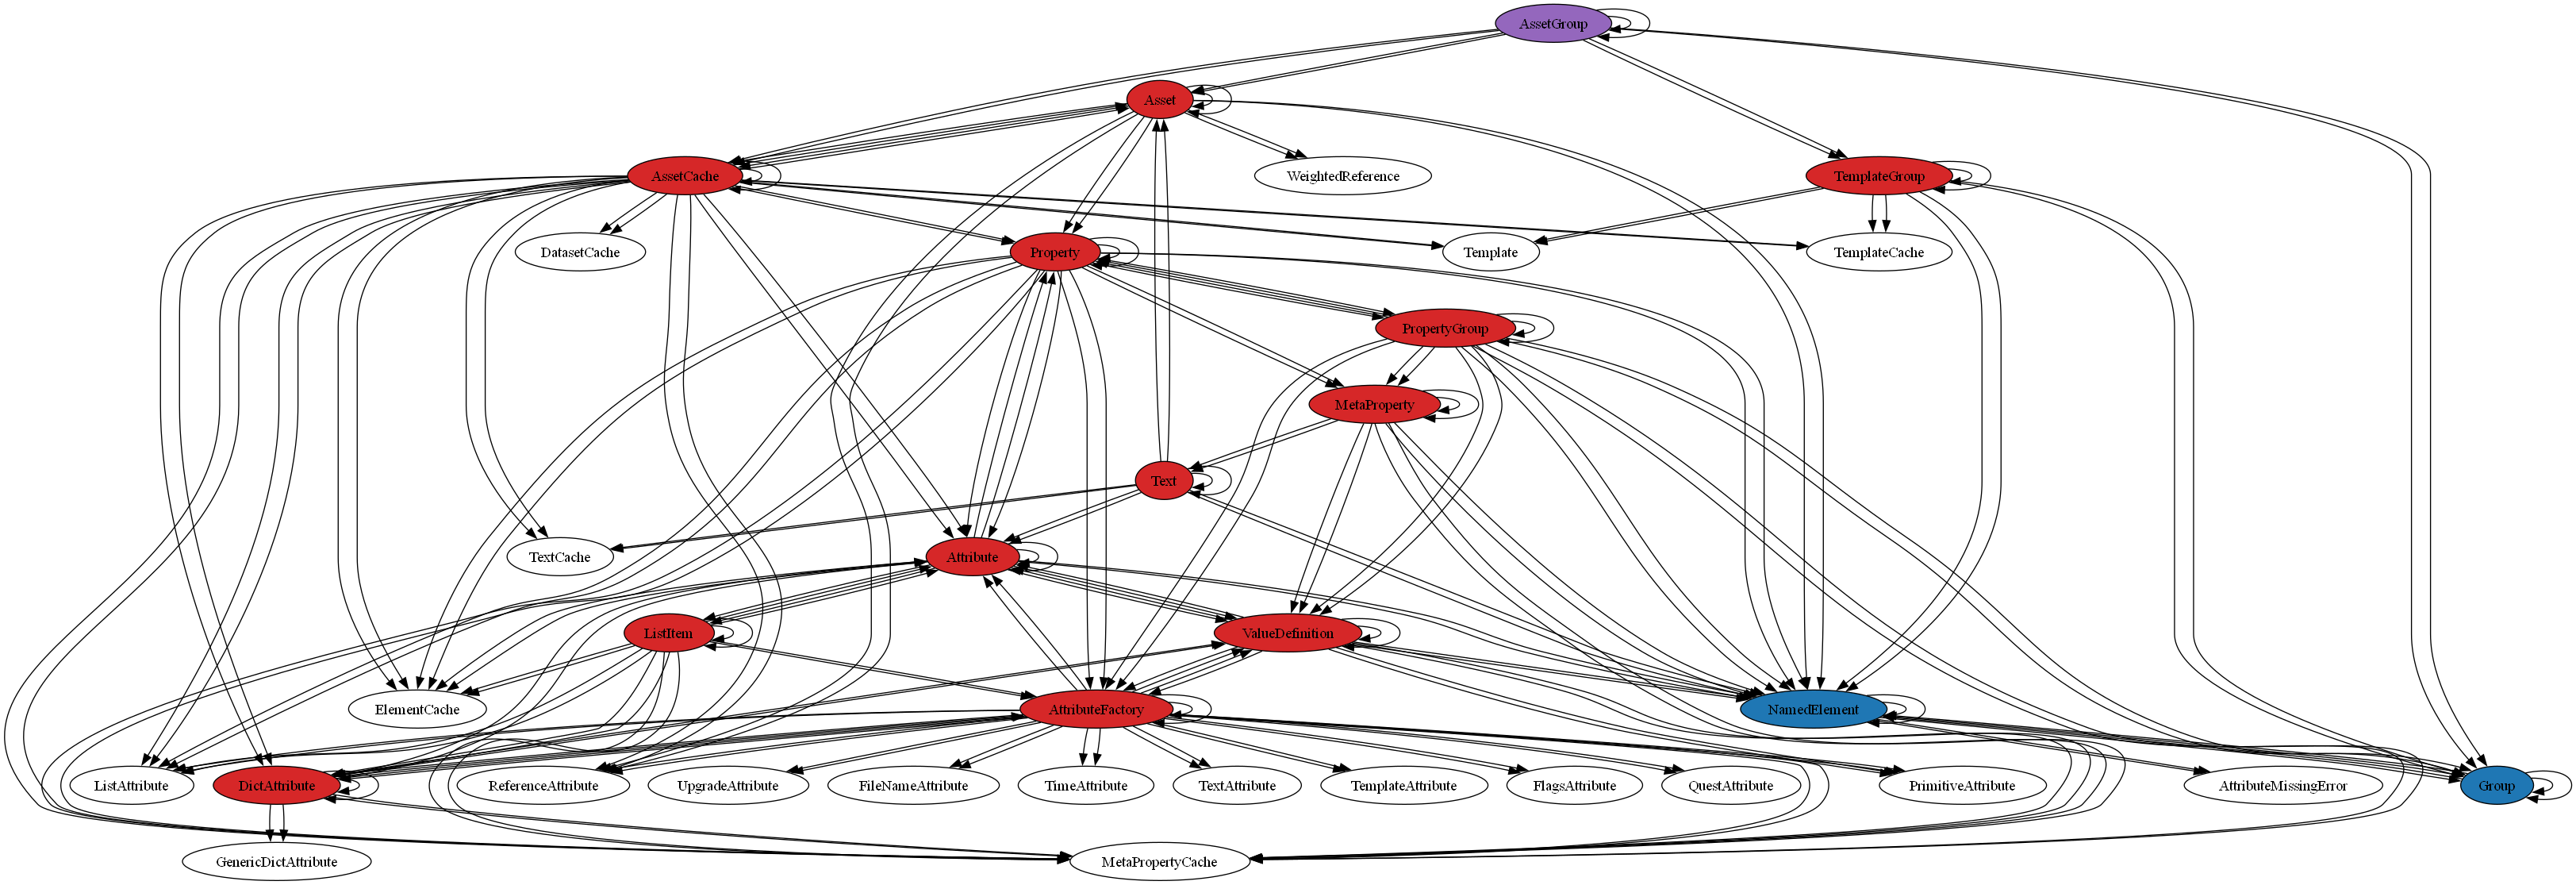

In [12]:
import ast
import os
from graphviz import Digraph
from IPython.display import Image, display
from networkx import DiGraph, strongly_connected_components

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'  # Adjust if Graphviz is not in PATH

def find_class_references(directory):
    class_references = {}
    
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(".py"):
                filepath = os.path.join(root, file)
                with open(filepath, "r", encoding="utf-8") as f:
                    try:
                        discarded = dict()
                        tree = ast.parse(f.read(), filename=filepath)
                        for node in ast.walk(tree):
                            if isinstance(node, ast.ClassDef):
                                class_name = node.name
                                if class_name not in class_references:
                                    class_references[class_name] = set()
                                for subnode in ast.walk(node):
                                    if isinstance(subnode, ast.Name):
                                        class_references[class_name].add(subnode.id)
                            elif isinstance(node, ast.If) and isinstance(node.test, ast.Attribute):
                                print(node)
                                # Exclude imports under "if t.TYPE_CHECKING:"
                                if (
                                    isinstance(node.test.value, ast.Name)
                                    and node.test.value.id == "t"
                                    and node.test.attr == "TYPE_CHECKING"
                                ):
                                    for subnode in ast.walk(node):
                                        if isinstance(subnode, ast.ImportFrom) or isinstance(subnode, ast.Import):
                                            for alias in subnode.names:
                                                for cls in class_references:
                                                    print(f"Discarding {cls} -> {alias.name}")
                                                    if cls in discarded:
                                                        discarded[cls].append(alias.name)
                                                    else:
                                                        discarded[cls] = [alias.name]
                        for cls, references in discarded.items():
                            for ref in references:
                                if ref in class_references:
                                    class_references[cls].discard(ref)
                    except SyntaxError:
                        pass  # Skip files with syntax errors
    return class_references

def generate_graph(class_references):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    dot = Digraph(comment="Class References")
    graph = DiGraph()

    # Add edges to the graph
    for cls, references in class_references.items():
        for ref in references:
            if ref in class_references and not ref.endswith("T"):  # Ensure the reference is also a class and exclude type hints
                graph.add_edge(cls, ref)

    # Find strongly connected components
    scc = list(strongly_connected_components(graph))
    color_map = list(mcolors.TABLEAU_COLORS.values())  # Use a predefined set of colors
    color_map *= (len(scc) // len(color_map)) + 1  # Repeat colors if needed

    # Assign colors to nodes based on their SCC
    node_colors = {}
    for idx, component in enumerate(scc):
        for node in component:
            node_colors[node] = color_map[idx]

    # Add nodes and edges to the Digraph with colors
    for cls, references in class_references.items():
        if cls in references:  # Only include classes in the graph
            dot.node(cls, style="filled", fillcolor=node_colors.get(cls, "white"))
            for ref in references:
                if ref in class_references and not ref.endswith("T"):
                    dot.edge(cls, ref)
    for cls, references in class_references.items():
        if cls in references:  # Only include classes in the graph
            dot.node(cls)
            for ref in references:
                if ref in class_references and not ref.endswith("T"):  # Ensure the reference is also a class and exclude type hints
                    dot.edge(cls, ref)
    output_file = "class_references"
    dot.render(output_file, format="png", cleanup=True)
    display(Image(filename=f"{output_file}.png"))

# Generate and display the graph
generate_graph(references)
